In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
from utils import (
    eda_tabular
)
print("Imported")

Imported successfully
Imported


In [2]:
X_train = pd.read_csv("../datasets/uci_har/har_dataset/train/X_train.txt",sep=r"\s+",header=None)
y_train = pd.read_csv("../datasets/uci_har/har_dataset/train/y_train.txt",names=["activity"],header=None)
X_test = pd.read_csv("../datasets/uci_har/har_dataset/test/X_test.txt",sep=r"\s+",header=None)
y_test = pd.read_csv("../datasets/uci_har/har_dataset/test/y_test.txt",names=["activity"],header=None)
features = pd.read_csv("../datasets/uci_har/har_dataset/features.txt",sep=r"\s+",header=None,names=["index","feature"])

X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

X.columns = features["feature"]

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (10299, 561)
Label shape: (10299, 1)


In [3]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [4]:
activity_names = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

y["activity_name"] = y["activity"].map(activity_names)

print(y["activity_name"].value_counts())

activity_name
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import(
    silhouette_score,
davies_bouldin_score,
calinski_harabasz_score,
adjusted_rand_score,
normalized_mutual_info_score
)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:",X_scaled.shape)

Scaled data shape: (10299, 561)


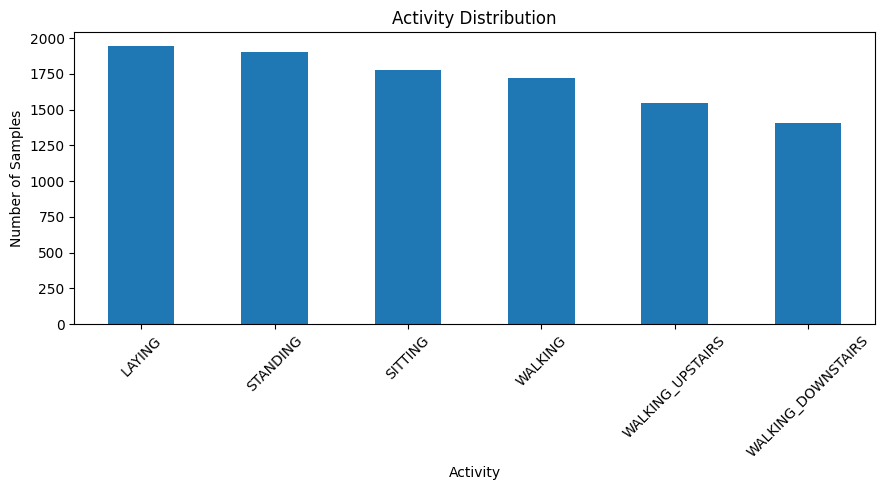

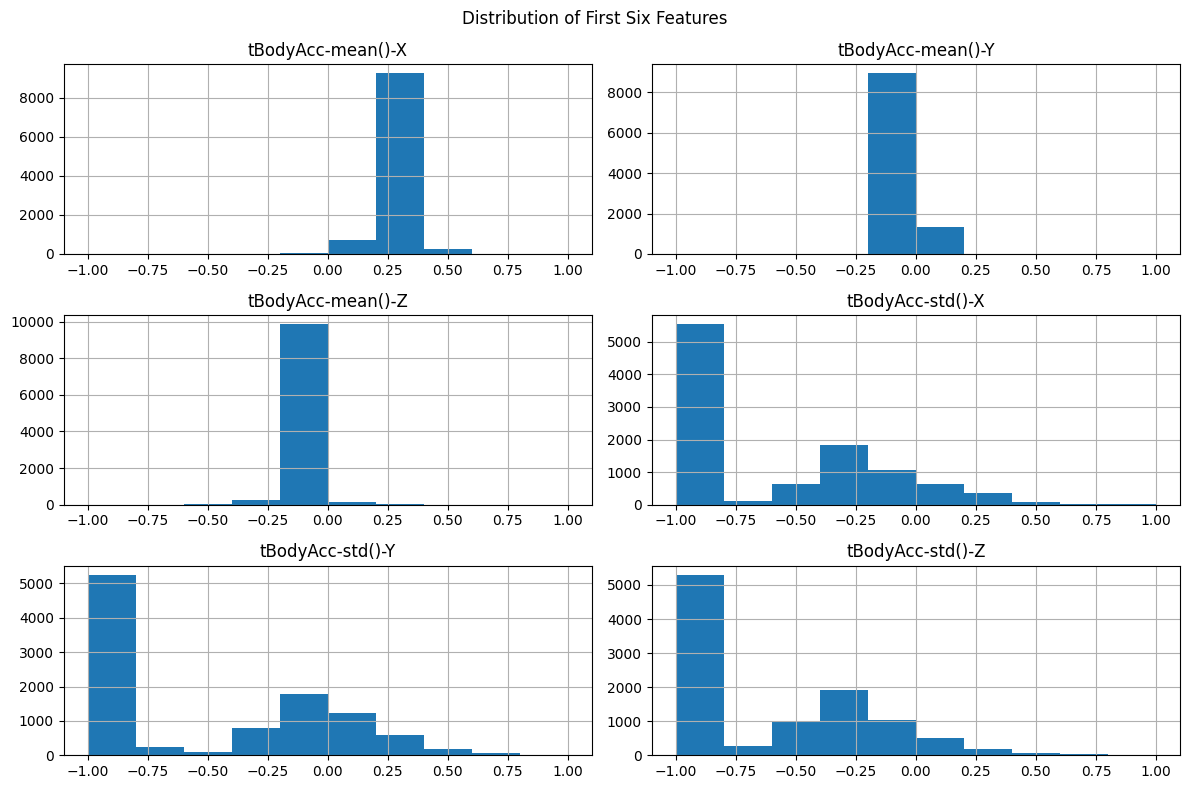

In [6]:
plt.figure(figsize=(9, 5))
y["activity_name"].value_counts().plot(kind="bar")
plt.title("Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X.iloc[:, :6].hist(figsize=(12, 8))
plt.suptitle("Distribution of First Six Features")
plt.tight_layout()
plt.show()

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.50738221 0.06239186]
Total explained variance: 0.5697740681020982


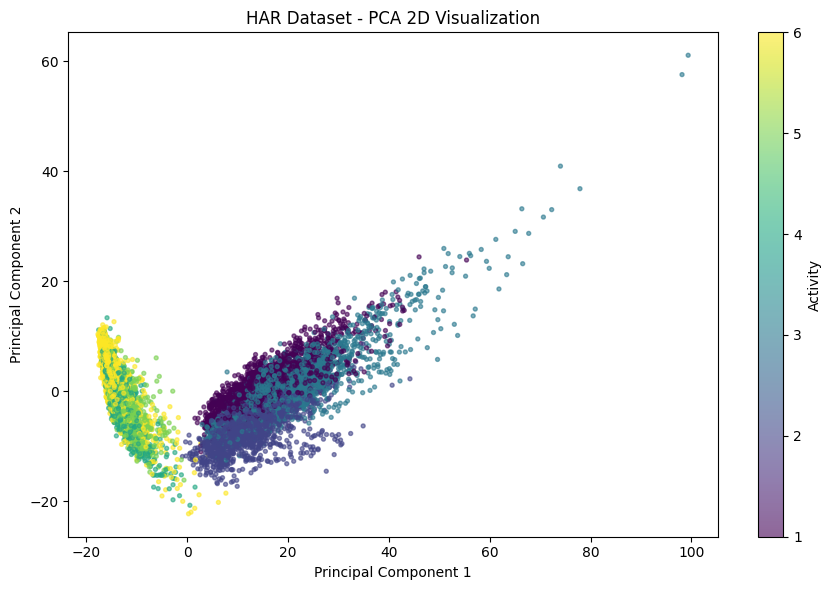

In [8]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y["activity"],
    s=8,
    alpha=0.6
)

plt.title("HAR Dataset - PCA 2D Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Activity")
plt.tight_layout()
plt.show()

In [9]:
k_values = range(2,8)
wcss = []
silhoutte_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled,labels))

kmeans_results = pd.DataFrame({
    "k":list(k_values),
    "WCSS":wcss,
    "Silhoutte Score":silhoutte_scores
})
print(kmeans_results)

   k          WCSS  Silhoutte Score
0  2  3.272857e+06         0.393732
1  3  2.921078e+06         0.315484
2  4  2.781602e+06         0.150005
3  5  2.654790e+06         0.128631
4  6  2.577180e+06         0.109895
5  7  2.519774e+06         0.081599


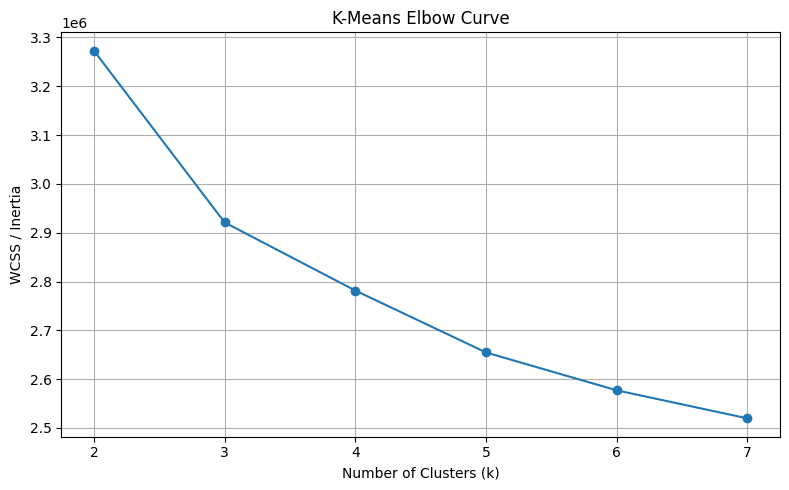

In [10]:
plt.figure(figsize=(8,5))
plt.plot(k_values,wcss,marker="o")
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

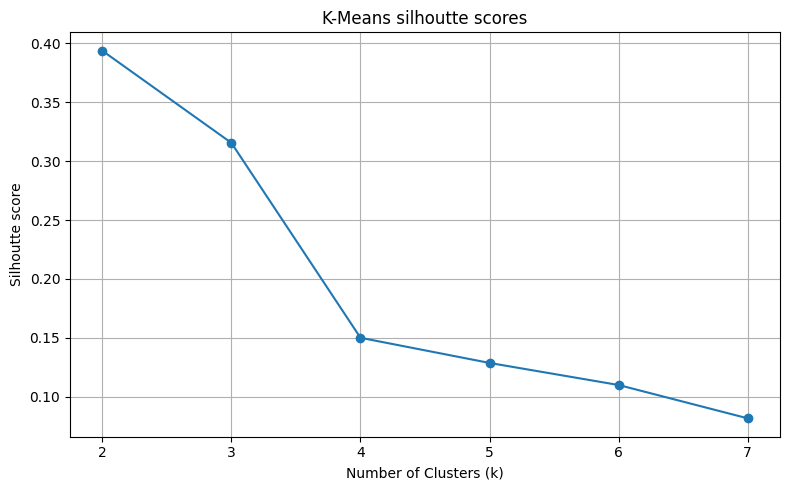

In [11]:
plt.figure(figsize=(8,5))
plt.plot(k_values, silhoutte_scores,marker="o")
plt.title("K-Means silhoutte scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhoutte score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
best_k = k_values[np.argmax(silhoutte_scores)]

print("Best k based on silhouette score:", best_k)

Best k based on silhouette score: 2


In [13]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means cluster sizes:
0    5620
1    4679
Name: count, dtype: int64


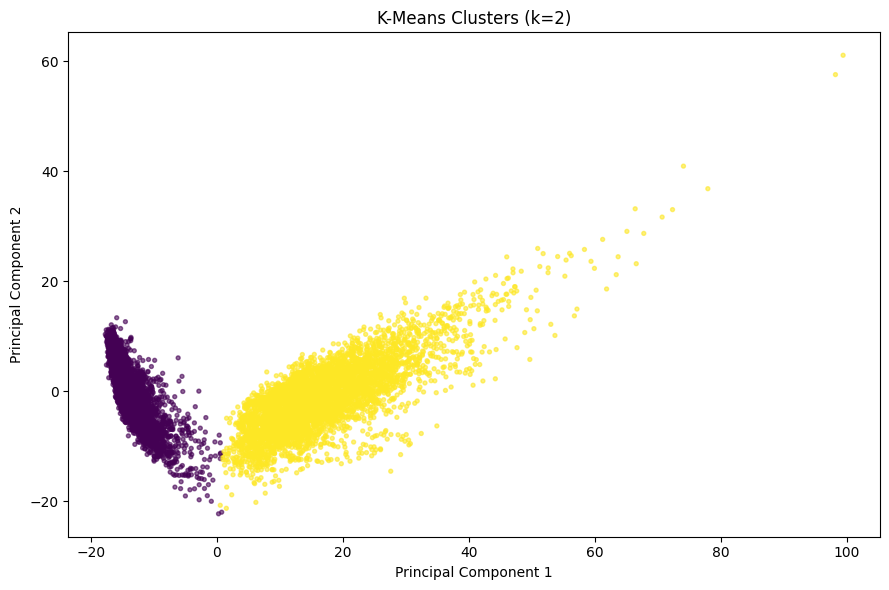

In [14]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=8,
    alpha=0.6
)

plt.title(f"K-Means Clusters (k={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

In [15]:
eps_values = [1, 2, 3, 4, 5, 6, 7, 8]
min_samples_values = [5, 10, 15]
dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        if n_clusters > 1:
            non_noise = labels != -1
            sil = silhouette_score(X_scaled[non_noise], labels[non_noise])
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette": sil
        })

dbscan_results = pd.DataFrame(dbscan_results)

print(dbscan_results)

    eps  min_samples  clusters  noise_points  silhouette
0     1            5         0         10299         NaN
1     1           10         0         10299         NaN
2     1           15         0         10299         NaN
3     2            5         0         10299         NaN
4     2           10         0         10299         NaN
5     2           15         0         10299         NaN
6     3            5         0         10299         NaN
7     3           10         0         10299         NaN
8     3           15         0         10299         NaN
9     4            5         0         10299         NaN
10    4           10         0         10299         NaN
11    4           15         0         10299         NaN
12    5            5         0         10299         NaN
13    5           10         0         10299         NaN
14    5           15         0         10299         NaN
15    6            5         0         10299         NaN
16    6           10         0 

In [16]:
valid_dbscan = dbscan_results.dropna(subset=["silhouette"])

if valid_dbscan.empty:
    print("No valid DBSCAN configuration found.")
else:
    best_dbscan_row = valid_dbscan.loc[valid_dbscan["silhouette"].idxmax()]

    best_eps = best_dbscan_row["eps"]
    best_min_samples = int(best_dbscan_row["min_samples"])

    print("Best eps:", best_eps)
    print("Best min_samples:", best_min_samples)

Best eps: 8.0
Best min_samples: 5


In [18]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan.fit_predict(X_scaled)

n_dbscan_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = np.sum(dbscan_labels == -1)

print("Number of clusters:", n_dbscan_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 5
Number of noise points: 10272


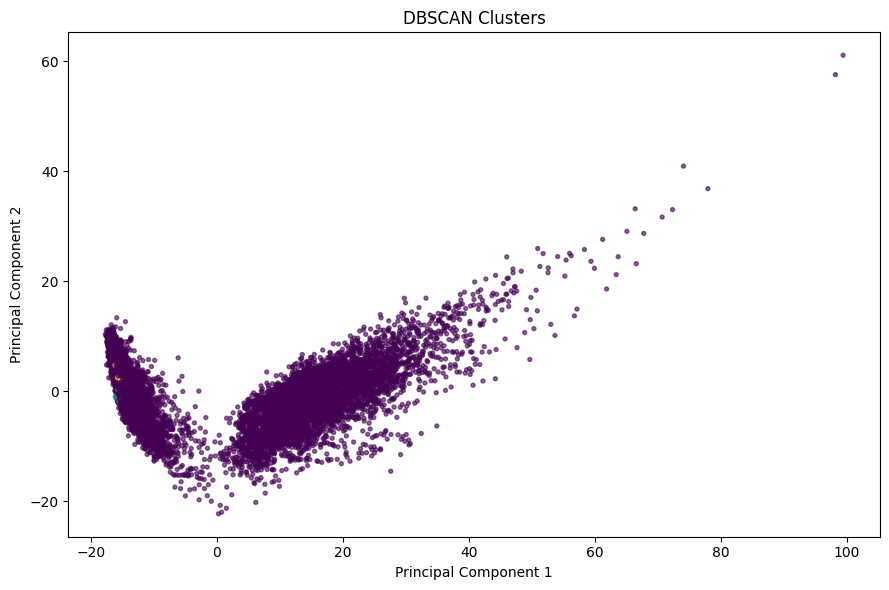

In [19]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.6
)

plt.title("DBSCAN Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

## Hierarchical Agglomerative clustering

In [21]:
hierachical = AgglomerativeClustering(
    n_clusters = best_k,
    linkage="ward"
)
hierachical_labels = hierachical.fit_predict(X_scaled)
print("Hierarchical cluster sizes:")
print(pd.Series(hierachical_labels).value_counts().sort_index())

Hierarchical cluster sizes:
0    4672
1    5627
Name: count, dtype: int64


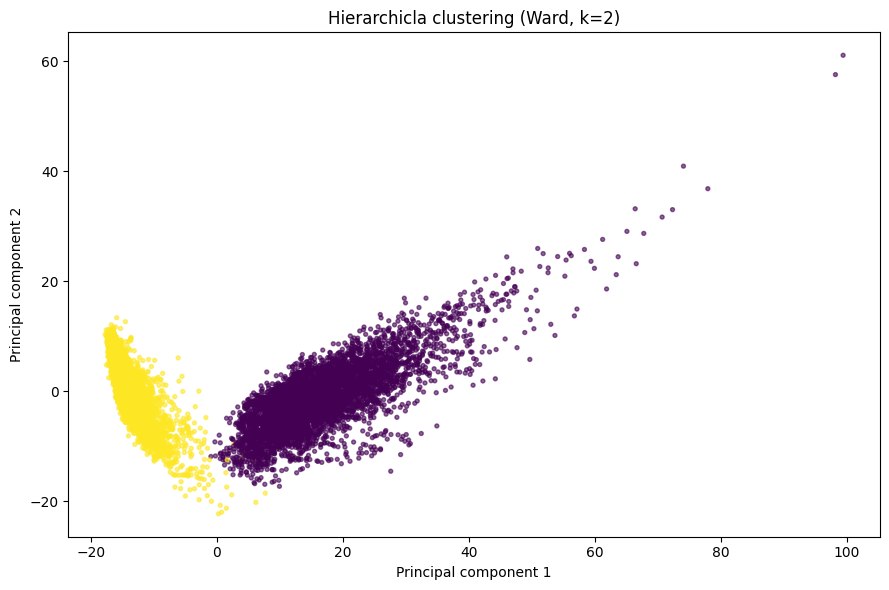

In [23]:
plt.figure(figsize = (9,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hierachical_labels,
    s=8,alpha=0.6
)
plt.title(f"Hierarchicla clustering (Ward, k={best_k})")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.tight_layout()
plt.show()

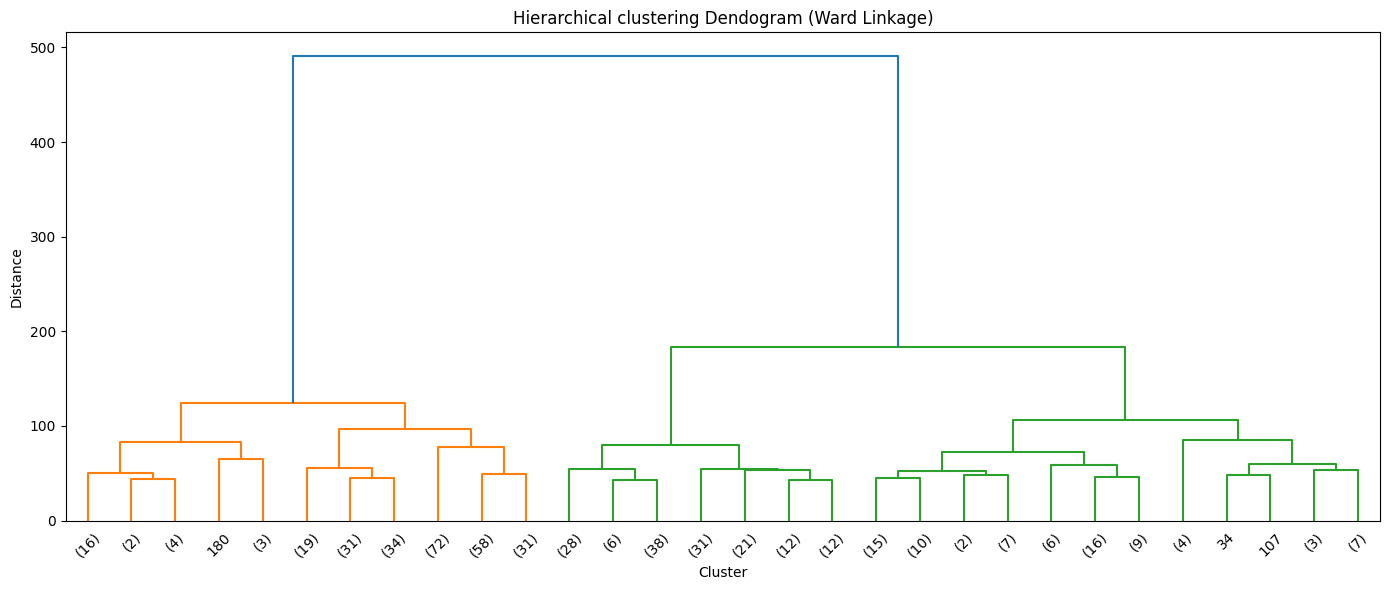

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage
sample_size = 500
sample_indices = np.random.RandomState(42).choice(
    len(X_scaled),size=sample_size,replace=False
)
X_sample = X_scaled[sample_indices]
Z = linkage(X_sample,method="ward")
plt.figure(figsize=(14,6))
dendrogram(
    Z, truncate_mode="lastp",p=30
)
plt.title("Hierarchical clustering Dendogram (Ward Linkage)")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [26]:
def evaluate_clustering(X_data, labels, true_labels):
    mask = labels != -1

    X_eval = X_data[mask]
    labels_eval = labels[mask]
    true_eval = true_labels[mask]

    if len(np.unique(labels_eval)) > 1:
        silhouette = silhouette_score(X_eval, labels_eval)
        davies_bouldin = davies_bouldin_score(X_eval, labels_eval)
        calinski = calinski_harabasz_score(X_eval, labels_eval)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski = np.nan

    ari = adjusted_rand_score(true_eval, labels_eval)
    nmi = normalized_mutual_info_score(true_eval, labels_eval)

    return [
        silhouette,
        davies_bouldin,
        calinski,
        ari,
        nmi
    ]

In [28]:
true_labels = y["activity"].values

kmeans_metrics = evaluate_clustering(
    X_scaled,
    kmeans_labels,
    true_labels
)

dbscan_metrics = evaluate_clustering(
    X_scaled,
    dbscan_labels,
    true_labels
)

hierarchical_metrics = evaluate_clustering(
    X_scaled,
    hierachical_labels,
    true_labels
)

results = pd.DataFrame(
    [kmeans_metrics, dbscan_metrics, hierarchical_metrics],
    columns=[
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz",
        "ARI",
        "NMI"
    ],
    index=[
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ]
)

print(results.round(4))

              Silhouette  Davies-Bouldin  Calinski-Harabasz     ARI     NMI
K-Means           0.3937          1.0707          7880.8139  0.3296  0.5455
DBSCAN            0.3650          0.9717            14.5078  0.1752  0.4611
Hierarchical      0.3934          1.0717          7859.7554  0.3325  0.5568


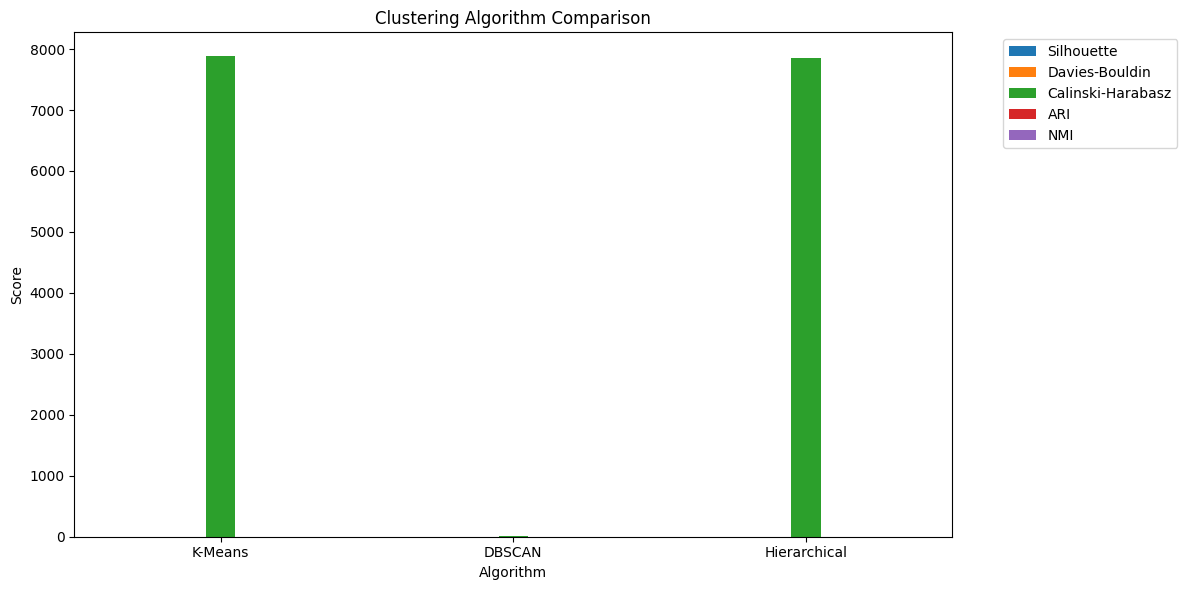

In [29]:
results.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Clustering Algorithm Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [30]:
print("========== FINAL RESULTS ==========")

print("\nK-Means")
print("Best k:", best_k)
print(kmeans_results.round(4))

print("\nDBSCAN")
print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Clusters:", n_dbscan_clusters)
print("Noise points:", n_noise)

print("\nComparison")
print(results.round(4))

========== FINAL RESULTS ==========

K-Means
Best k: 2
   k          WCSS  Silhoutte Score
0  2  3.272857e+06           0.3937
1  3  2.921078e+06           0.3155
2  4  2.781602e+06           0.1500
3  5  2.654790e+06           0.1286
4  6  2.577180e+06           0.1099
5  7  2.519774e+06           0.0816

DBSCAN
Best eps: 8.0
Best min_samples: 5
Clusters: 5
Noise points: 10272

Comparison
              Silhouette  Davies-Bouldin  Calinski-Harabasz     ARI     NMI
K-Means           0.3937          1.0707          7880.8139  0.3296  0.5455
DBSCAN            0.3650          0.9717            14.5078  0.1752  0.4611
Hierarchical      0.3934          1.0717          7859.7554  0.3325  0.5568
